# BREAST CANCER DETECTION USING CNN-BASED CLASSIFICATION
## Gladys Ouma

### A1. Problem Definition

Breast cancer is one of the major diseases for which mammography is used to identify abnormalities within breast tissue. Mammograms can contain different types of abnormalities, including masses and calcifications. A calcification is build up of calcium salts in the body tissue causing it to harden. A mass may be benign or malignant, and distinguishing between these categories is an important part of breast-imaging.

This project focuses on **mammographic masses** and investigates whether a Convolutional Neural Network (CNN) can learn visual patterns from mammography images that distinguish **benign** masses from **malignant** masses. The project therefore is formulated as a **binary image-classification**.

The two target classes are:

- **Benign:** The mammographic mass is classified as non-cancerous.
- **Malignant:** The mammographic mass is classified as cancerous.

The original dataset contains a third category, `BENIGN_WITHOUT_CALLBACK`. `BENIGN_WITHOUT_CALLBACK` will be grouped with `BENIGN`, while `MALIGNANT` will remain the malignant class.

Two CNN experiments will be performed.

The first model will receive a **cropped image** containing the mammographic mass. This experiments whether focusing on the region with abnormality will produce results with more precision as compared to the second model that uses full mamography.

- **Body part:** Breast
- **Imaging modality:** Mammography
- **Problem type:** Binary image classification
- **Target classes:** Benign and Malignant
- **Negative class:** Benign (label 0)
- **Positive class:** Malignant (label 1)


In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import random
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [4]:

train_df = pd.read_csv("mass_case_description_train_set.csv")
test_df = pd.read_csv("mass_case_description_test_set.csv")

display(train_df.head(5))

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


### A2. Dataset Documentation

#### 2.1 Dataset Overview

This project uses the **CBIS-DDSM (Curated Breast Imaging Subset of the Digital Database for Screening Mammography)** dataset. The dataset used contains mammography cases involving abnormalities such as masses and calcifications. The analysis is restricted to the **mass cases**.

The supplied mass datasets are:
- mass_case_description_train_set.csv
- mass_case_description_test_set.csv

The training dataset contains:
- 1,318 records
- 691 patients

The test dataset contains:
- 378 records
- 201 patients

Therefore, the supplied mass data contains:
- 1,696 records
- 892 patient records across the training and test datasets

#### 2.2 Target Variable

The original pathology field contains three categories:
- BENIGN
- MALIGNANT
- BENIGN_WITHOUT_CALLBACK

The resulting labels are:

| Binary label | Meaning |
|---:|---|
| 0 | Benign |
| 1 | Malignant |

#### 2.3 Training Class Distribution

The supplied mass training dataset contains:

| Original pathology | Number of records |
|---|---:|
| BENIGN | 577 |
| BENIGN_WITHOUT_CALLBACK | 104 |
| MALIGNANT | 637 |

After converting the labels to binary classes:

| Model class | Number of records |
|---|---:|
| Benign | 681 |
| Malignant | 637 |

#### 2.4 Test Class Distribution

The supplied mass test dataset contains:

| Original pathology | Number of records |
|---|---:|
| BENIGN | 194 |
| BENIGN_WITHOUT_CALLBACK | 37 |
| MALIGNANT | 147 |

After binary conversion:

| Model class | Number of records |
|---|---:|
| Benign | 231 |
| Malignant | 147 |

#### 2.5 Image Data

The dataset provides paths for different forms of mammography imagery, including:
- Full mammography images
- Cropped images containing the abnormality
- ROI (Region of Interest) masks

For the primary experiment, the **cropped abnormality image** will be used as the CNN input and for the comparison experiment, the **full mammography image** will be used.

The image dimensions are inspected programmatically during data preparation because medical images may have different resolutions and aspect ratios.

#### 2.6 Dataset Metadata

The CSV files contain several metadata fields.
Important fields include:

- patient_id
- breast density
- left or right breast
- image view
- abnormality id
- abnormality type
- mass shape
- mass margins
- assessmen
- pathology
- subtlety
- image file path
- cropped image file path
- ROI mask file path

#### 2.7 Mammographic Views

The dataset contains different mammographic views, including:

- CC — craniocaudal view
- MLO — mediolateral oblique view

The distribution of views will be examined during exploratory data analysis.

#### 2.8 Dataset Limitations

Several limitations must be considered.

*  Multiple records can originate from the same patient. Therefore, randomly splitting individual records can result in the same patient appearing in both training and validation data.

* The dataset may not represent the full diversity of patients, imaging equipment, acquisition protocols, and populations encountered in real clinical practice.


In [5]:
def convert_label(pathology):
    pathology = str(pathology).strip().upper()

    if pathology in ["BENIGN", "BENIGN_WITHOUT_CALLBACK"]:
        return 0

    if pathology == "MALIGNANT":
        return 1

    return np.nan


train_df["label"] = train_df["pathology"].apply(convert_label)
test_df["label"] = test_df["pathology"].apply(convert_label)

train_df["label_name"] = train_df["label"].map({
    0: "Benign",
    1: "Malignant"
})

test_df["label_name"] = test_df["label"].map({
    0: "Benign",
    1: "Malignant"
})

train_df = train_df.dropna(subset=["label"]).copy()
test_df = test_df.dropna(subset=["label"]).copy()

train_df["label"] = train_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

print(train_df["label_name"].value_counts())
print()
print(test_df["label_name"].value_counts())

label_name
Benign       681
Malignant    637
Name: count, dtype: int64

label_name
Benign       231
Malignant    147
Name: count, dtype: int64


['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path', 'label', 'label_name']


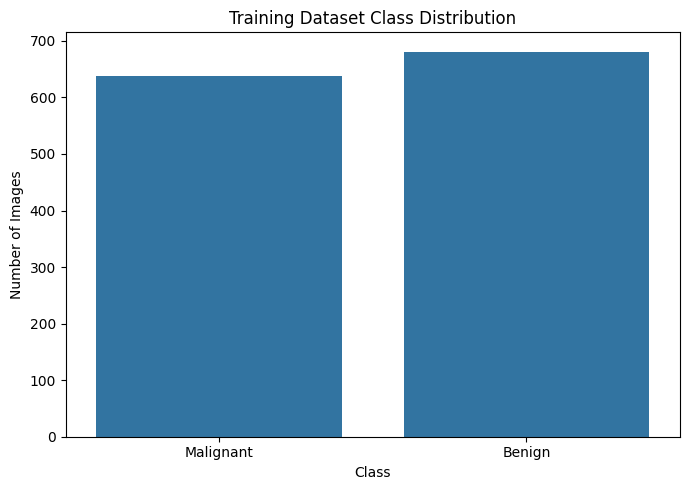

In [6]:
print(train_df.columns.tolist())

train_df["label_name"] = train_df["label"].map({
    0: "Benign",
    1: "Malignant"
})

plt.figure(figsize=(7, 5))

sns.countplot(
    data=train_df,
    x="label_name"
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [7]:
patient_labels = (
    train_df
    .groupby("patient_id")["label"]
    .max()
    .reset_index()
)

patient_labels.columns = ["patient_id", "patient_label"]

print(patient_labels.head())
print("\nPatient-level class distribution:")
print(patient_labels["patient_label"].value_counts())


  patient_id  patient_label
0    P_00001              1
1    P_00004              0
2    P_00009              1
3    P_00015              1
4    P_00018              0

Patient-level class distribution:
patient_label
1    346
0    345
Name: count, dtype: int64


In [8]:
train_patients, val_patients = train_test_split(
    patient_labels["patient_id"],
    test_size=0.20,
    random_state=SEED,
    stratify=patient_labels["patient_label"]
)
train_split = train_df[
    train_df["patient_id"].isin(train_patients)
].copy()

val_split = train_df[
    train_df["patient_id"].isin(val_patients)
].copy()

test_split = test_df.copy()

print("Training records:", len(train_split))
print("Validation records:", len(val_split))
print("Test records:", len(test_split))

print("\nUnique training patients:",
      train_split["patient_id"].nunique())

print("Unique validation patients:",
      val_split["patient_id"].nunique())

print("Unique test patients:",
      test_split["patient_id"].nunique())

Training records: 1060
Validation records: 258
Test records: 378

Unique training patients: 552
Unique validation patients: 139
Unique test patients: 201


In [9]:
def show_distribution(df, name):

    counts = df["label"].value_counts().sort_index()
    percentages = (
        df["label"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )

    print(f"\n{name}")
    print("-" * 40)

    print(
        f"Benign:    {counts.get(0, 0)} "
        f"({percentages.get(0, 0):.2f}%)"
    )

    print(
        f"Malignant: {counts.get(1, 0)} "
        f"({percentages.get(1, 0):.2f}%)"
    )


show_distribution(train_split, "TRAINING")
show_distribution(val_split, "VALIDATION")
show_distribution(test_split, "TEST")


TRAINING
----------------------------------------
Benign:    552 (52.08%)
Malignant: 508 (47.92%)

VALIDATION
----------------------------------------
Benign:    129 (50.00%)
Malignant: 129 (50.00%)

TEST
----------------------------------------
Benign:    231 (61.11%)
Malignant: 147 (38.89%)


In [10]:
train_patient_check = (
    train_split
    .groupby("patient_id")["label"]
    .max()
)

val_patient_check = (
    val_split
    .groupby("patient_id")["label"]
    .max()
)

print("TRAINING PATIENTS")
print(train_patient_check.value_counts().sort_index())

print("\nVALIDATION PATIENTS")
print(val_patient_check.value_counts().sort_index())

TRAINING PATIENTS
label
0    276
1    276
Name: count, dtype: int64

VALIDATION PATIENTS
label
0    69
1    70
Name: count, dtype: int64


### A3. Data Preparation
The raw mammography JPEG images cannot be passed directly into the CNN because the images may have different dimensions and pixel-value ranges.
The general pipeline is:
* Converting th eimages to appropriate color format
* Resizing the images to a standard size - I am using 224 by 224 because it gives a consistent input size while keeping computational requirements manageable.  A standard input size is necessary since the original images have variable dimensions.
* Normalising image pixel values for consistency
* Data augmentation to ensure transformations does not create unrealistic mammographic appearances
* Label encoding to convert labels into binary classes
* Spliting data into training and validation subsets
* Data leakage prevention 



In [11]:
from pathlib import Path

IMAGE_DIR = Path("/home/student/medical-imaging/jpeg")

jpeg_files = [
    path
    for path in IMAGE_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg"}
]

print("Total JPEG files:", len(jpeg_files))
print("First 5 files:")

for path in jpeg_files[:5]:
    print(path)

Total JPEG files: 10238
First 5 files:
/home/student/medical-imaging/jpeg/1.3.6.1.4.1.9590.100.1.2.125446310913058496142468381631295976603/2-025.jpg
/home/student/medical-imaging/jpeg/1.3.6.1.4.1.9590.100.1.2.125446310913058496142468381631295976603/1-047.jpg
/home/student/medical-imaging/jpeg/1.3.6.1.4.1.9590.100.1.2.206548514011121207219994124060615579686/1-171.jpg
/home/student/medical-imaging/jpeg/1.3.6.1.4.1.9590.100.1.2.62342979012199834720157331730700370563/1-116.jpg
/home/student/medical-imaging/jpeg/1.3.6.1.4.1.9590.100.1.2.3429204713582358109609880820394708456/1-092.jpg


In [12]:
jpeg_by_uid = {}

for path in jpeg_files:
    uid = path.parent.name
    jpeg_by_uid.setdefault(uid, []).append(path)

print("Unique JPEG UID folders:", len(jpeg_by_uid))

multi_file_folders = {
    uid: paths
    for uid, paths in jpeg_by_uid.items()
    if len(paths) > 1
}

print("UID folders containing multiple JPEGs:", len(multi_file_folders))
for uid, paths in list(multi_file_folders.items())[:10]:
    print("\nUID:", uid)
    for path in paths:
        print("  ", path.name)

Unique JPEG UID folders: 6775
UID folders containing multiple JPEGs: 3463

UID: 1.3.6.1.4.1.9590.100.1.2.125446310913058496142468381631295976603
   2-025.jpg
   1-047.jpg

UID: 1.3.6.1.4.1.9590.100.1.2.3429204713582358109609880820394708456
   1-092.jpg
   2-091.jpg

UID: 1.3.6.1.4.1.9590.100.1.2.139771837411189773724611706141740282715
   1-286.jpg
   2-264.jpg

UID: 1.3.6.1.4.1.9590.100.1.2.99933945612504876136587449881888946699
   1-207.jpg
   2-208.jpg

UID: 1.3.6.1.4.1.9590.100.1.2.130752011311500478428034705110433499415
   1-039.jpg
   2-040.jpg

UID: 1.3.6.1.4.1.9590.100.1.2.142190242410115865303742841971978703320
   2-004.jpg
   1-005.jpg

UID: 1.3.6.1.4.1.9590.100.1.2.58671166011167603620988174693978747239
   2-183.jpg
   1-261.jpg

UID: 1.3.6.1.4.1.9590.100.1.2.86254599111567721135368096072734935094
   1-059.jpg
   2-217.jpg

UID: 1.3.6.1.4.1.9590.100.1.2.417805589012069056131665837120044721729
   1-128.jpg
   2-129.jpg

UID: 1.3.6.1.4.1.9590.100.1.2.367665435112247022525649483

In [13]:
import re

def extract_uids(path_string):
    return re.findall(
        r"1\.3\.6\.1\.4\.1\.9590\.100\.1\.2\.\d+",
        str(path_string)
    )

example_path = train_df["image file path"].iloc[0]
example_uids = extract_uids(example_path)

print("Example full-image CSV path:")
print(example_path)

print("\nUIDs found:")
for i, uid in enumerate(example_uids, start=1):
    print(f"UID {i}: {uid}")

print("\nJPEG matches:")
for i, uid in enumerate(example_uids, start=1):
    print(
        f"UID {i}: {len(jpeg_by_uid.get(uid, []))} JPEG file(s)"
    )


Example full-image CSV path:
Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm

UIDs found:
UID 1: 1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994
UID 2: 1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515

JPEG matches:
UID 1: 0 JPEG file(s)
UID 2: 1 JPEG file(s)


In [14]:
def check_uid_positions(df, column):
    first_matches = 0
    second_matches = 0
    no_matches = 0

    for value in df[column]:
        uids = extract_uids(value)

        first_exists = len(uids) >= 1 and uids[0] in jpeg_by_uid
        second_exists = len(uids) >= 2 and uids[1] in jpeg_by_uid

        if first_exists:
            first_matches += 1

        if second_exists:
            second_matches += 1

        if not first_exists and not second_exists:
            no_matches += 1

    return first_matches, second_matches, no_matches


for name, df in [
    ("TRAIN", train_split),
    ("VALIDATION", val_split),
    ("TEST", test_split)
]:
    results = check_uid_positions(df, "image file path")

    print(name)
    print("First UID matches :", results[0])
    print("Second UID matches:", results[1])
    print("No UID matches    :", results[2])
    print()


TRAIN
First UID matches : 0
Second UID matches: 1060
No UID matches    : 0

VALIDATION
First UID matches : 0
Second UID matches: 258
No UID matches    : 0

TEST
First UID matches : 0
Second UID matches: 378
No UID matches    : 0



In [15]:
def get_unique_full_jpeg_path(csv_path):
    uids = extract_uids(csv_path)

    if len(uids) < 2:
        return None

    matches = jpeg_by_uid.get(uids[1], [])

    if len(matches) != 1:
        return None

    return matches[0]


In [16]:
for df in [train_split, val_split, test_split]:
    df["jpeg_path"] = df["image file path"].apply(
        get_unique_full_jpeg_path
    )

print("Missing JPEG paths:")
print("Training   :", train_split["jpeg_path"].isna().sum())
print("Validation :", val_split["jpeg_path"].isna().sum())
print("Test       :", test_split["jpeg_path"].isna().sum())

assert train_split["jpeg_path"].notna().all()
assert val_split["jpeg_path"].notna().all()
assert test_split["jpeg_path"].notna().all()


Missing JPEG paths:
Training   : 0
Validation : 0
Test       : 0


In [17]:
def count_multiple_jpeg_records(df, column):
    count = 0

    for value in df[column]:
        uids = extract_uids(value)

        if len(uids) >= 2:
            matches = jpeg_by_uid.get(uids[1], [])

            if len(matches) > 1:
                count += 1

    return count


print("Cropped records with multiple JPEGs:")
print("Training   :", count_multiple_jpeg_records(train_split, "cropped image file path"))
print("Validation :", count_multiple_jpeg_records(val_split, "cropped image file path"))
print("Test       :", count_multiple_jpeg_records(test_split, "cropped image file path"))

print("\nFull records with multiple JPEGs:")
print("Training   :", count_multiple_jpeg_records(train_split, "image file path"))
print("Validation :", count_multiple_jpeg_records(val_split, "image file path"))
print("Test       :", count_multiple_jpeg_records(test_split, "image file path"))


Cropped records with multiple JPEGs:
Training   : 983
Validation : 243
Test       : 367

Full records with multiple JPEGs:
Training   : 0
Validation : 0
Test       : 0


In [18]:
train_patient_set = set(train_split["patient_id"])
val_patient_set = set(val_split["patient_id"])
test_patient_set = set(test_split["patient_id"])

print("Train/Validation patient overlap:", len(train_patient_set & val_patient_set))
print("Train/Test patient overlap:", len(train_patient_set & test_patient_set))
print("Validation/Test patient overlap:", len(val_patient_set & test_patient_set))

assert len(train_patient_set & val_patient_set) == 0
assert len(train_patient_set & test_patient_set) == 0
assert len(val_patient_set & test_patient_set) == 0

assert len(train_split) + len(val_split) == len(train_df)
assert len(test_split) == len(test_df)

print("\nNo patient overlap detected.")
print("Dataset integrity checks passed.")

Train/Validation patient overlap: 0
Train/Test patient overlap: 0
Validation/Test patient overlap: 0

No patient overlap detected.
Dataset integrity checks passed.


In [19]:
from pathlib import Path
from PIL import Image
import numpy as np

JPEG_ROOT = Path("/home/student/medical-imaging/jpeg")


def get_cropped_image_from_uid(row):
    uids = extract_uids(row["cropped image file path"])

    if len(uids) < 2:
        return None

    cropped_uid = uids[1]

    matches = jpeg_by_uid.get(cropped_uid, [])

    if not matches:
        return None

    if len(matches) == 1:
        return str(matches[0])

    candidates = []

    for path in matches:
        try:
            with Image.open(path) as img:
                arr = np.asarray(img)

                unique_values = len(np.unique(arr))
                nonzero_fraction = np.mean(arr > 5)
                std = np.std(arr)

                candidates.append({
                    "path": path,
                    "unique_values": unique_values,
                    "nonzero_fraction": nonzero_fraction,
                    "std": std
                })

        except Exception:
            continue

    if not candidates:
        return None

    candidates.sort(
        key=lambda x: (
            x["unique_values"],
            x["nonzero_fraction"],
            x["std"]
        ),
        reverse=True
    )

    return str(candidates[0]["path"])

In [ ]:
train_split["cropped_jpeg_path"] = train_split.apply(
    get_cropped_image_from_uid,
    axis=1
)

val_split["cropped_jpeg_path"] = val_split.apply(
    get_cropped_image_from_uid,
    axis=1
)

test_split["cropped_jpeg_path"] = test_split.apply(
    get_cropped_image_from_uid,
    axis=1
)

print("Training cropped images:", train_split["cropped_jpeg_path"].notna().sum())
print("Validation cropped images:", val_split["cropped_jpeg_path"].notna().sum())
print("Test cropped images:", test_split["cropped_jpeg_path"].notna().sum())

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 1

IMAGE_SIZE = (224, 224)


def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label

In [ ]:
sample_paths = train_split["jpeg_path"].head(5).tolist()

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, path in enumerate(sample_paths):
    with Image.open(path) as img:
        original = np.asarray(img)

    processed = load_image(
        tf.constant(str(path)),
        tf.constant(0.0)
    )[0].numpy().squeeze()

    axes[0, i].imshow(original, cmap="gray")
    axes[0, i].set_title(f"Original\n{original.shape}")
    axes[0, i].axis("off")

    axes[1, i].imshow(processed, cmap="gray")
    axes[1, i].set_title(f"Processed\n{processed.shape}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.02),
    layers.RandomZoom(
        height_factor=0.05,
        width_factor=0.05
    ),
    layers.RandomTranslation(
        height_factor=0.03,
        width_factor=0.03
    )
], name="data_augmentation")




In [ ]:
sample_path = str(train_split["jpeg_path"].iloc[0])

sample_bytes = tf.io.read_file(sample_path)

sample_image = tf.image.decode_jpeg(
    sample_bytes,
    channels=1
)

sample_image = tf.image.resize(
    sample_image,
    IMAGE_SIZE
)

sample_image = tf.cast(
    sample_image,
    tf.float32
) / 255.0

sample_tensor = tf.expand_dims(
    sample_image,
    axis=0
)

plt.figure(figsize=(12, 8))

for i in range(6):

    augmented = data_augmentation(
        sample_tensor,
        training=True
    )

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        augmented[0].numpy().squeeze(),
        cmap="gray"
    )

    plt.axis("off")
    plt.title(f"Augmented {i + 1}")

plt.tight_layout()
plt.show()


### A4. Model Architecture & Justification

#### Model Selection

A Convolutional Neural Network (CNN) is used because cancer detection is an image-classification problem. CNNs are designed to learn spatial patterns from images. The network learns visual features from mammography images and use those features to distinguish between benign and malignant masses.

Two models are trained:
1. A CNN using cropped abnormality images.
2. A CNN using full mammography images.

The two models uses the same general architecture so that the primary difference between the experiments is the image input. CNN is suitable because it can automatically learn hierarchical visual features.


In [ ]:
def build_cnn(input_shape=(224, 224, 1)):

    model = keras.Sequential([

        layers.Input(shape=input_shape),

        data_augmentation,

        layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            128,
            (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            256,
            (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.30),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dropout(0.20),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model


model = build_cnn()

model.summary()

In [ ]:
trainable_params = np.sum([
    np.prod(variable.shape)
    for variable in model.trainable_variables
])

print("Trainable parameters:", trainable_params)


### Training Process

The CNN is trained to minimize classification error when distinguishing benign from malignant mammographic masses.

#### Loss Function

Because this is a binary classification problem, binary cross-entropy will be used as the primary loss function. The loss measures the difference between the model's predicted probability and the actual class label.

#### Training Curves

Training and validation accuracy will be plotted across epochs.
Training and validation loss will also be plotted.
These curves will be used to determine whether:

- The model is learning effectively.
- The model is underfitting.
- The model is overfitting.
- Training should have stopped earlier.


In [ ]:
import tensorflow as tf
import numpy as np

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16


def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, tf.cast(label, tf.float32)


train_paths = train_split["jpeg_path"].astype(str).values
train_labels = train_split["label"].astype(int).values


val_paths = val_split["jpeg_path"].astype(str).values
val_labels = val_split["label"].astype(int).values


test_paths = test_split["jpeg_path"].astype(str).values
test_labels = test_split["label"].astype(int).values


ds_train = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

ds_val = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

ds_test = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)


ds_train = (
    ds_train
    .shuffle(
        buffer_size=len(train_paths),
        seed=42
    )
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ds_val = (
    ds_val
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ds_test = (
    ds_test
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


print("Training samples:", len(train_paths))
print("Validation samples:", len(val_paths))
print("Test samples:", len(test_paths))

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

print("Datasets created successfully.")

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf
from tensorflow import keras

LEARNING_RATE = 1e-4
EPOCHS = 15


classes = train_split["label"].astype(int).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weight = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Class weights (Benign, Malignant):", class_weight)
print("Training samples:", len(train_split))
print("Validation samples:", len(val_split))


model = keras.Sequential([
    keras.layers.Input(shape=(224, 224, 1)),
    
    data_augmentation, 

    keras.layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), padding="same", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(256, (3, 3), padding="same", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")
])


model.summary()


model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)


callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "mammogram_cnn_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("STARTING CNN TRAINING")

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)

print("CNN TRAINING COMPLETE")
print("Best model saved as: mammogram_cnn_best.keras")

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


### A6. Model Evaluation

The final model is evaluated on the **official test set**, which was not used during training or validation.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Correct prediction examples
- Incorrect prediction examples

Recall is particularly important to inspect because false negatives correspond to malignant cases predicted as benign.


In [ ]:
test_results = model.evaluate(
    test_dataset,
    return_dict=True
)

print("Test set results:")
for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")


In [ ]:
y_true = test_labels.astype(int)

y_probability = model.predict(
    test_dataset,
    verbose=1
).ravel()

y_pred = (
    y_probability >= 0.50
).astype(int)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malignant"],
        zero_division=0
    )
)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

print("Confusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Confusion Matrix - Official Test Set")
plt.show()


In [ ]:
test_results_df = test_split.copy()

test_results_df["probability_malignant"] = y_probability
test_results_df["predicted_label"] = y_pred
test_results_df["true_label"] = y_true
test_results_df["correct"] = (
    test_results_df["true_label"]
    == test_results_df["predicted_label"]
)

correct_examples = test_results_df[
    test_results_df["correct"]
].head(2)

incorrect_examples = test_results_df[
    ~test_results_df["correct"]
].head(2)

print("Correct examples:")
display(
    correct_examples[
        [
            "patient_id",
            "image view",
            "pathology",
            "probability_malignant",
            "predicted_label",
            "jpeg_path"
        ]
    ]
)

print("\nIncorrect examples:")
display(
    incorrect_examples[
        [
            "patient_id",
            "image view",
            "pathology",
            "probability_malignant",
            "predicted_label",
            "jpeg_path"
        ]
    ]
)


In [ ]:
examples = pd.concat(
    [
        correct_examples.assign(example_type="Correct"),
        incorrect_examples.assign(example_type="Incorrect")
    ]
)

fig, axes = plt.subplots(
    1,
    len(examples),
    figsize=(12, 5)
)

if len(examples) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, examples.iterrows()):
    with Image.open(row["jpeg_path"]) as img:
        image = np.asarray(img)

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f'{row["example_type"]}\n'
        f'True: {"Malignant" if row["true_label"] else "Benign"}\n'
        f'Pred: {"Malignant" if row["predicted_label"] else "Benign"}\n'
        f'P(Malignant): {row["probability_malignant"]:.2f}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


### A7. Model Saving & Inference Preprocessing

The trained CNN is saved in Keras `.keras` format. The same preprocessing used during evaluation is required during inference:

**JPEG → grayscale → 224 × 224 → float32 → divide by 255 → CNN → malignant probability**




In [ ]:
FINAL_MODEL_PATH = "mammography_mass_classifier_v2.keras"

model.save(FINAL_MODEL_PATH)

print("Model saved to:", FINAL_MODEL_PATH)
print("File exists:", Path(FINAL_MODEL_PATH).exists())
